# ARV-DS03 — Gemma 4 E2B : QLoRA + localisation visuelle (quadrants)

Version **E2B** (plus légère que E4B, passe confortablement sur T4 Kaggle).
Deux parties :

**Partie A — Fine-tuning QLoRA** pour la classification 3 classes
(`normal`, `suspected_opacity`, `uncertain`) — livrable **COULD**.

**Partie B — Localisation visuelle qualitative** : on demande au modèle dans quel
**quadrant** (gauche/droite × supérieur/moyen/inférieur) se situe l'opacité, et on
compare à la **vraie boîte englobante RSNA** affichée sur l'image — livrable **COULD**.

> Un VLM génératif n'est pas un détecteur d'objets : on vise une localisation
> *qualitative* (zone), pas des coordonnées en pixels. C'est l'approche honnête et
> défendable à l'oral.

**Prérequis :** GPU T4 activé, `HF_TOKEN` dans les Secrets Kaggle, conditions acceptées
sur `google/gemma-4-E2B-it` (modèle gated).


## 0. Un seul GPU + gestion mémoire

À exécuter **en tout premier**, avant tout import de torch.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import torch
print(f"GPU utilisé : {torch.cuda.memory_allocated(0)/1e9:.2f} Go")
# Doit afficher environ 0.00 Go juste après un redémarrage

GPU utilisé : 0.00 Go


## 1. Installation des dépendances

Si Kaggle propose de redémarrer le kernel après cette cellule, accepte, puis reprends à la cellule suivante.

In [3]:
!pip install -q -U "transformers>=5.10.1" accelerate datasets trl "peft>=0.19.0" bitsandbytes pydicom opencv-python scikit-learn
!pip install -q "pillow==11.1.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 84.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.8/838.8 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 94.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.2

## 2. Imports et authentification Hugging Face

In [4]:
import os, json, time, torch, numpy as np, pandas as pd, cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

login(UserSecretsClient().get_secret("HF_TOKEN"))

import transformers
print("transformers :", transformers.__version__)
print("CUDA         :", torch.cuda.get_device_name(0))
print("bf16 support :", torch.cuda.is_bf16_supported())

transformers : 5.12.1
CUDA         : Tesla T4
bf16 support : True


## 3. Données RSNA, mapping 3 classes, split 80/20 + boîtes englobantes

On charge deux fichiers :
- `stage_2_detailed_class_info.csv` → les 3 classes textuelles (pour la classification)
- `stage_2_train_labels.csv` → les **boîtes englobantes** `x, y, width, height` (pour la localisation, partie B)

In [5]:
import glob

# Recherche automatique du dossier RSNA (robuste aux differents chemins Kaggle)
matches = glob.glob('/kaggle/input/**/stage_2_detailed_class_info.csv', recursive=True)
if not matches:
    raise FileNotFoundError("Dataset RSNA introuvable. Verifie qu'il est bien attache (Add Input).")
BASE_DIR = os.path.dirname(matches[0]) + '/'
TRAIN_IMAGES_DIR = os.path.join(BASE_DIR, 'stage_2_train_images')
print("BASE_DIR detecte :", BASE_DIR)

# Classes (1 ligne par patient)
df_class = pd.read_csv(os.path.join(BASE_DIR, 'stage_2_detailed_class_info.csv'))
df_class = df_class.drop_duplicates(subset='patientId').reset_index(drop=True)

CLASS_MAP = {
    "Normal": "normal",
    "Lung Opacity": "suspected_opacity",
    "No Lung Opacity / Not Normal": "uncertain",
}
df_class["label"] = df_class["class"].map(CLASS_MAP)
print("\nRepartition complete :")
print(df_class["label"].value_counts(), "\n")

# Boites englobantes (plusieurs lignes par patient possible) -> pour la partie B
df_boxes = pd.read_csv(os.path.join(BASE_DIR, 'stage_2_train_labels.csv'))
print("Lignes avec boite (Target=1) :", int(df_boxes["Target"].sum()))

from sklearn.model_selection import train_test_split

train_df, eval_df = train_test_split(
    df_class, test_size=0.20, stratify=df_class["label"], random_state=42
)
print(f"\nBloc train (80%) : {len(train_df)}  |  Bloc eval (20%) : {len(eval_df)}")

N_TRAIN = 800
train_sub, _ = train_test_split(
    train_df, train_size=N_TRAIN, stratify=train_df["label"], random_state=42
)
N_EVAL = 300
eval_sub, _ = train_test_split(
    eval_df, train_size=N_EVAL, stratify=eval_df["label"], random_state=42
)
train_sub = train_sub.reset_index(drop=True)
eval_sub  = eval_sub.reset_index(drop=True)
print(f"Echantillon train LoRA : {len(train_sub)}  |  Echantillon eval : {len(eval_sub)}")

BASE_DIR detecte : /kaggle/input/competitions/rsna-pneumonia-detection-challenge/

Repartition complete :
label
uncertain            11821
normal                8851
suspected_opacity     6012
Name: count, dtype: int64 

Lignes avec boite (Target=1) : 9555

Bloc train (80%) : 21347  |  Bloc eval (20%) : 5337
Echantillon train LoRA : 800  |  Echantillon eval : 300


## 4. Prétraitement DICOM → PIL RGB

In [6]:
import pydicom

def process_dicom(patient_id, size=(448, 448)):
    """Lit un DICOM, normalise, applique CLAHE, retourne une image PIL RGB."""
    path = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")
    if not os.path.exists(path):
        return None
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255.0
    img = img.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img_rgb).resize(size)

_test = process_dicom(train_sub.iloc[0]["patientId"])
print("Image test :", _test.size, _test.mode)

Image test : (448, 448) RGB


---
# Partie A — Fine-tuning QLoRA (classification 3 classes)
---

## 5. Chargement de Gemma 4 E2B en 4-bit (QLoRA)

Seul changement vs E4B : `MODEL_ID = google/gemma-4-E2B-it`. Modèle ~2× plus petit, marge mémoire confortable sur T4. On charge le modèle **avant** de tokeniser le dataset (la tokenisation a besoin du `processor`).

In [7]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(f"Mémoire libérée. GPU utilisé : {torch.cuda.memory_allocated(0)/1e9:.2f} Go")

Mémoire libérée. GPU utilisé : 0.00 Go


In [8]:
from transformers import AutoProcessor, AutoModelForMultimodalLM, BitsAndBytesConfig

MODEL_ID = "google/gemma-4-E2B-it"  
compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print("compute_dtype :", compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    dtype=compute_dtype,
)
print("Gemma 4 E2B charge en 4-bit.")

compute_dtype : torch.bfloat16


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Gemma 4 E2B charge en 4-bit.


## 6. Construction des exemples d'entraînement (image → JSON cible)

> ⚠️ Cibles avec `confidence: 0.9` / `image_quality: "good"` fixes : seul
> `predicted_class` compte pour les métriques.

In [9]:
import random

CLASS_DETAILS = {
    "normal": {
        "justifications": [
            "Lung fields appear clear without focal opacity.",
            "No evidence of consolidation or airspace disease.",
            "Symmetric aeration with sharp costophrenic angles.",
        ],
        "evidence": ["clear lung fields", "no focal consolidation", "preserved costophrenic angles"],
    },
    "suspected_opacity": {
        "justifications": [
            "A region of increased opacity is visible, suggesting possible consolidation.",
            "Focal airspace opacity raises suspicion for an abnormal process.",
            "Asymmetric density warrants attention for possible opacity.",
        ],
        "evidence": ["focal increased density", "possible airspace opacity", "ill-defined borders"],
    },
    "uncertain": {
        "justifications": [
            "Findings are equivocal and do not clearly fit a single category.",
            "Image features are non-specific; confident classification is not possible.",
            "Ambiguous appearance; further review would be required.",
        ],
        "evidence": ["ambiguous findings", "limited image clarity", "non-specific markings"],
    },
}

# --- Constantes réinjectées à l'inférence (le modèle n'a pas à les apprendre) ---
FIXED_LIMITATIONS = ["educational prototype, single frontal view"]
FIXED_WARNING = "Prototype pedagogique. Non destine au diagnostic medical."

def build_target_json(label):
    """Cible D'ENTRAINEMENT minimale : on ne garde que ce qui porte la décision.
    Le signal de loss se concentre sur predicted_class / confidence / justification."""
    d = CLASS_DETAILS[label]
    conf = round(random.uniform(0.55, 0.7), 2) if label == "uncertain" else round(random.uniform(0.8, 0.95), 2)
    return json.dumps({
        "predicted_class": label,
        "confidence": conf,
        "justification": random.choice(d["justifications"]),
    }, ensure_ascii=False)

INSTRUCTION = """You are an educational radiology assistant (not a clinician).
Analyze this frontal chest X-ray and classify it as: normal, suspected_opacity, or uncertain.
Return ONLY valid JSON with keys: predicted_class, confidence, justification."""

def make_example(row):
    img = process_dicom(row["patientId"])
    if img is None:
        return None
    return {
        "messages": [
            {"role": "user", "content": [
                {"type": "image", "image": img},
                {"type": "text", "text": INSTRUCTION},
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": build_target_json(row["label"])},
            ]},
        ]
    }



from sklearn.utils import resample

target_n = train_sub["label"].value_counts().max()  # 355 (uncertain)
balanced_parts = []
for label in train_sub["label"].unique():
    part = train_sub[train_sub["label"] == label]
    if len(part) < target_n:
        part = resample(part, replace=True, n_samples=target_n, random_state=42)
    balanced_parts.append(part)

train_sub_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)
print("Distribution après rééquilibrage :")
print(train_sub_balanced["label"].value_counts())

# Construction des exemples à partir du train rééquilibré
train_records = [e for e in (make_example(r) for _, r in train_sub_balanced.iterrows()) if e]
print("Exemples prets :", len(train_records))
print("Exemple de cible :", build_target_json("normal"))
print("Exemple de cible :", build_target_json("suspected_opacity"))

Distribution après rééquilibrage :
label
normal               355
uncertain            355
suspected_opacity    355
Name: count, dtype: int64
Exemples prets : 1065
Exemple de cible : {"predicted_class": "normal", "confidence": 0.91, "justification": "No evidence of consolidation or airspace disease."}
Exemple de cible : {"predicted_class": "suspected_opacity", "confidence": 0.82, "justification": "Focal airspace opacity raises suspicion for an abnormal process."}


## 7. Configuration LoRA + collator vision

In [10]:
from peft import LoraConfig

model.config.use_cache = False

peft_config = LoraConfig(
    r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    # Regex : ne cible QUE les projections d'attention DANS le modele de langage,
    # pas celles de l'encodeur vision (Gemma4ClippableLinear non supporte par PEFT).
    target_modules=r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj)$",
)
def collate_fn(examples):
    messages = [ex["messages"] for ex in examples]
    batch = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        padding=True,
        add_generation_prompt=False,
    )
    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    # --- Masquage du prompt : on ne garde la loss qu'après "<|turn>model\n" ---
    # Tokens du marqueur de début de réponse assistant
    start_marker = processor.tokenizer("<|turn>model\n", add_special_tokens=False)["input_ids"]
    m = len(start_marker)
    marker_t = torch.tensor(start_marker, device=batch["input_ids"].device)

    for i in range(batch["input_ids"].shape[0]):
        ids = batch["input_ids"][i]
        # cherche la dernière occurrence du marqueur dans la séquence
        found = -1
        for j in range(len(ids) - m, -1, -1):
            if torch.equal(ids[j:j+m], marker_t):
                found = j + m  # position juste après le marqueur
                break
        if found > 0:
            labels[i, :found] = -100  # masque tout AVANT la réponse

    if "mm_token_type_ids" not in batch:
        batch["mm_token_type_ids"] = torch.zeros_like(batch["input_ids"])
    batch["labels"] = labels
    return batch

In [11]:
test_batch = collate_fn([train_records[0], train_records[1]])
for i in range(2):
    kept = (test_batch["labels"][i] != -100).sum().item()
    total = (test_batch["input_ids"][i] != processor.tokenizer.pad_token_id).sum().item()
    kept_ids = test_batch["input_ids"][i][test_batch["labels"][i] != -100]
    print(f"Exemple {i}: {kept}/{total} tokens gardés")
    print("  Texte gardé:", repr(processor.tokenizer.decode(kept_ids)))

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Exemple 0: 36/352 tokens gardés
  Texte gardé: '{"predicted_class": "normal", "confidence": 0.83, "justification": "Symmetric aeration with sharp costophrenic angles."}<turn|>\n'
Exemple 1: 38/354 tokens gardés
  Texte gardé: '{"predicted_class": "uncertain", "confidence": 0.69, "justification": "Findings are equivocal and do not clearly fit a single category."}<turn|>\n'


## 8. Entraînement LoRA (1 epoch)

Sur E2B + T4, comptez ~10-20 min pour 800 images. On peut voir la `loss` décroitre.

In [12]:
import logging
import warnings
from transformers.utils import logging as hf_logging

# Réduit la verbosité de transformers aux vraies erreurs (masque les warnings répétés,
# notamment "Kwargs passed to processor.__call__" qui spamme à chaque batch).
# Toutefois le padding fonctionne correctement. Ce warning n'est que "cosmétique" (due à un décalage de version).
hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=".*Kwargs passed to.*")

In [13]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="/kaggle/working/gemma4e2b-rsna-lora",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_steps=20,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="epoch",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    optim="paged_adamw_8bit",
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True},
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_records,
    peft_config=peft_config,
    data_collator=collate_fn,
    args=training_args,
)

trainer.train()
trainer.save_model("/kaggle/working/gemma4e2b-rsna-lora")
print("Entrainement termine, adaptateur sauvegarde.")

{'loss': '3.261', 'grad_norm': '3.906', 'learning_rate': '9e-05', 'entropy': '0.2235', 'num_tokens': '1.409e+04', 'mean_token_accuracy': '0.6804', 'epoch': '0.03756'}
{'loss': '1.507', 'grad_norm': '1.398', 'learning_rate': '0.00019', 'entropy': '0.3318', 'num_tokens': '2.822e+04', 'mean_token_accuracy': '0.753', 'epoch': '0.07512'}
{'loss': '0.7284', 'grad_norm': '1.07', 'learning_rate': '0.0001993', 'entropy': '0.6794', 'num_tokens': '4.235e+04', 'mean_token_accuracy': '0.7902', 'epoch': '0.1127'}
{'loss': '0.4466', 'grad_norm': '0.9297', 'learning_rate': '0.0001971', 'entropy': '0.5125', 'num_tokens': '5.646e+04', 'mean_token_accuracy': '0.8589', 'epoch': '0.1502'}
{'loss': '0.2723', 'grad_norm': '1.023', 'learning_rate': '0.0001933', 'entropy': '0.3458', 'num_tokens': '7.053e+04', 'mean_token_accuracy': '0.9015', 'epoch': '0.1878'}
{'loss': '0.2045', 'grad_norm': '1.008', 'learning_rate': '0.0001879', 'entropy': '0.2456', 'num_tokens': '8.461e+04', 'mean_token_accuracy': '0.9217', 

In [14]:
# Verifier que l'entrainement a bien appris
hist = trainer.state.log_history
losses = [h["loss"] for h in hist if "loss" in h]
print("Nombre de points de loss :", len(losses))
print("Valeurs de loss :", [round(l, 3) for l in losses])
if losses:
    print(f"\nPremiere loss : {losses[0]:.3f}  ->  Derniere loss : {losses[-1]:.3f}")
    print("Tendance :", "DECROISSANTE (bon)" if losses[-1] < losses[0] else "PLATE/CROISSANTE (a creuser)")

Nombre de points de loss : 26
Valeurs de loss : [3.261, 1.507, 0.728, 0.447, 0.272, 0.204, 0.174, 0.162, 0.172, 0.163, 0.161, 0.165, 0.152, 0.142, 0.154, 0.145, 0.146, 0.146, 0.145, 0.142, 0.148, 0.145, 0.15, 0.144, 0.145, 0.137]

Premiere loss : 3.261  ->  Derniere loss : 0.137
Tendance : DECROISSANTE (bon)


## 9. Évaluation de la classification (300 images d'éval)

In [15]:
row = eval_sub.iloc[0]
img = process_dicom(row["patientId"])
msgs = [{"role": "user", "content": [
    {"type": "image", "image": img},
    {"type": "text", "text": INSTRUCTION},
]}]
inputs = processor.apply_chat_template(
    msgs, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
)
for k, v in inputs.items():
    try:
        print(k, tuple(v.shape))
    except AttributeError:
        print(k, type(v))

input_ids (1, 316)
attention_mask (1, 316)
mm_token_type_ids (1, 316)
pixel_values (1, 2520, 768)
image_position_ids (1, 2520, 2)


In [16]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm.auto import tqdm

ALLOWED = {"normal", "suspected_opacity", "uncertain"}
model.config.use_cache = True
model.eval()
model.gradient_checkpointing_disable()
# Gemma 4 : generate() valide image_position_ids comme "inutilisé" alors que le
# vision tower en a besoin. On neutralise cette validation trop stricte.
model._validate_model_kwargs = lambda *args, **kwargs: None

# --- Champs constants réinjectés à l'inférence (garantis par le code, pas le modèle) ---
FIXED_LIMITATIONS = ["educational prototype, single frontal view"]
FIXED_WARNING = "Prototype pedagogique. Non destine au diagnostic medical."

def _generate_json(row):
    """Appel modèle commun : retourne le dict JSON minimal produit, ou un repli."""
    img = process_dicom(row["patientId"])
    if img is None:
        return {"predicted_class": "uncertain", "confidence": 0.0, "justification": "Image illisible."}
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": INSTRUCTION},
    ]}]
    inputs = processor.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(model.device)
    inputs.pop("mm_token_type_ids", None)
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=80, do_sample=False,
                             use_cache=True, logits_to_keep=1)
    text = processor.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    try:
        s, e = text.find("{"), text.rfind("}") + 1
        return json.loads(text[s:e])
    except Exception:
        return {"predicted_class": "uncertain", "confidence": 0.0, "justification": "Parsing failed."}

def predict(row):
    """Pour l'EVALUATION : ne renvoie que la classe (avec garde-fou d'incertitude)."""
    pred = _generate_json(row)
    cls = pred.get("predicted_class")
    if cls not in ALLOWED or pred.get("confidence", 0) < 0.6:
        cls = "uncertain"
    return cls

def build_full_output(model_json, image_quality="adequate"):
    """Reconstruit le JSON COMPLET attendu par le cahier des charges."""
    cls = model_json.get("predicted_class", "uncertain")
    conf = model_json.get("confidence", 0.0)
    #if cls not in ALLOWED or conf < 0.3:
        #cls = "uncertain"
    return {
        "image_quality": image_quality,
        "predicted_class": cls,
        "confidence": conf,
        "justification": model_json.get("justification", "No justification produced."),
        "limitations": FIXED_LIMITATIONS,
        "warning": FIXED_WARNING,
    }

def predict_full(row, image_quality="adequate"):
    """Pour la DEMO : renvoie le JSON complet (warning inclus)."""
    return build_full_output(_generate_json(row), image_quality)

# ---------------- Boucle d'évaluation (métriques) ----------------
preds, trues = [], []
for _, row in tqdm(eval_sub.iterrows(), total=len(eval_sub)):
    preds.append(predict(row))
    trues.append(row["label"])

labels = ["normal", "suspected_opacity", "uncertain"]
acc = accuracy_score(trues, preds)
f1  = f1_score(trues, preds, labels=labels, average="macro")
unc = (np.array(preds) == "uncertain").mean()

print(f"Accuracy        : {acc:.4f}")
print(f"Macro-F1        : {f1:.4f}")
print(f"Taux incertitude: {unc:.4f}")
print("\n", classification_report(trues, preds, labels=labels, zero_division=0))
print(pd.DataFrame(confusion_matrix(trues, preds, labels=labels), index=labels, columns=labels))

pd.DataFrame({"patientId": eval_sub["patientId"], "true": trues, "pred": preds}) \
  .to_csv("/kaggle/working/gemma4e2b_finetuned_results.csv", index=False)
print("\nResultats sauvegardes.")

  0%|          | 0/300 [00:00<?, ?it/s]

Accuracy        : 0.4067
Macro-F1        : 0.3141
Taux incertitude: 0.6133

                    precision    recall  f1-score   support

           normal       0.31      0.34      0.32        99
suspected_opacity       0.60      0.04      0.08        68
        uncertain       0.46      0.64      0.54       133

         accuracy                           0.41       300
        macro avg       0.46      0.34      0.31       300
     weighted avg       0.44      0.41      0.36       300

                   normal  suspected_opacity  uncertain
normal                 34                  1         64
suspected_opacity      30                  3         35
uncertain              47                  1         85

Resultats sauvegardes.


In [17]:
import json
exemple = predict_full(eval_sub.iloc[0])
print(json.dumps(exemple, indent=2, ensure_ascii=False))

{
  "image_quality": "adequate",
  "predicted_class": "uncertain",
  "confidence": 0.68,
  "justification": "Findings are equivocal and do not clearly fit a single category.",
  "limitations": [
    "educational prototype, single frontal view"
  ],
  "warning": "Prototype pedagogique. Non destine au diagnostic medical."
}


In [18]:
ex = train_records[0]
for m in ex["messages"]:
    print(m["role"], ":", m["content"] if isinstance(m["content"], str) else
          [c.get("text", c.get("type")) for c in m["content"]])

user : ['image', 'You are an educational radiology assistant (not a clinician).\nAnalyze this frontal chest X-ray and classify it as: normal, suspected_opacity, or uncertain.\nReturn ONLY valid JSON with keys: predicted_class, confidence, justification.']
assistant : ['{"predicted_class": "normal", "confidence": 0.83, "justification": "Symmetric aeration with sharp costophrenic angles."}']


In [19]:
print("Distribution train_sub :")
print(train_sub["label"].value_counts())
print("\nProportions :")
print(train_sub["label"].value_counts(normalize=True).round(3))

Distribution train_sub :
label
uncertain            355
normal               265
suspected_opacity    180
Name: count, dtype: int64

Proportions :
label
uncertain            0.444
normal               0.331
suspected_opacity    0.225
Name: proportion, dtype: float64


---
# Partie B — Localisation visuelle qualitative (quadrants)
---

## 10. Vérité terrain : quadrant d'une boîte RSNA

Le dataset donne des boîtes `x, y, width, height` en pixels sur l'image DICOM
d'origine. On convertit le **centre** de chaque boîte en quadrant :
- horizontal : `left` / `right` (note : sur une radio, le côté gauche de l'image
  correspond au poumon **droit** du patient — on reste ici en repère image pour
  rester simple et vérifiable visuellement)
- vertical : `upper` / `middle` / `lower`

On récupère la taille réelle de l'image dans le DICOM pour normaliser.

In [20]:
def get_dicom_size(patient_id):
    """Retourne (hauteur, largeur) de l'image DICOM d'origine."""
    path = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")
    dcm = pydicom.dcmread(path)
    return dcm.pixel_array.shape  # (H, W)

def box_to_quadrant(x, y, w, h, img_h, img_w):
    """Convertit une boite (coin haut-gauche + dimensions) en quadrant qualitatif."""
    cx, cy = x + w / 2, y + h / 2
    horiz = "left" if cx < img_w / 2 else "right"
    if cy < img_h / 3:
        vert = "upper"
    elif cy < 2 * img_h / 3:
        vert = "middle"
    else:
        vert = "lower"
    return f"{vert}-{horiz}"

# Patients avec opacite (au moins une boite) presents dans notre eval set
eval_ids = set(eval_sub["patientId"])
boxes_eval = df_boxes[(df_boxes["Target"] == 1) & (df_boxes["patientId"].isin(eval_ids))].copy()
print("Boites disponibles dans l'eval set :", len(boxes_eval))
print(boxes_eval.head())

Boites disponibles dans l'eval set : 114
                                patientId      x      y  width  height  Target
312  06c50ad5-8ffd-480b-8424-dd38df7ca86c  574.0   99.0  325.0   744.0       1
536  0862f2ff-7e56-4cd1-8c26-c3f25a86d257  622.0  100.0  269.0   762.0       1
537  0862f2ff-7e56-4cd1-8c26-c3f25a86d257  279.0  218.0  253.0   402.0       1
656  0953df2c-f969-4fa1-a872-022475ecd5ef  168.0  325.0  232.0   293.0       1
657  0953df2c-f969-4fa1-a872-022475ecd5ef  509.0  310.0  195.0   301.0       1


## 11. Demander au modèle une localisation par quadrant

In [21]:
LOCALIZE_PROMPT = """You are an educational radiology assistant (not a clinician).
This frontal chest X-ray shows a suspected lung opacity.
In which region of the image is the most prominent opacity located?
Answer with ONLY valid JSON:
{"vertical":"upper|middle|lower","horizontal":"left|right","note":"short visual description"}
Use the image reference frame (left = left side of the image)."""

def localize(patient_id):
    img = process_dicom(patient_id)
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": LOCALIZE_PROMPT},
    ]}]
    inputs = processor.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(model.device)
    inputs.pop("mm_token_type_ids", None)
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=120, do_sample=False,
                             use_cache=True, logits_to_keep=1)
    text = processor.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    try:
        s, e = text.find("{"), text.rfind("}") + 1
        pred = json.loads(text[s:e])
        v = pred.get("vertical", "?")
        hor = pred.get("horizontal", "?")
        return f"{v}-{hor}", pred.get("note", "")
    except Exception:
        return "parse_error", text[:80]

# Test sur un patient avec opacite
demo_id = boxes_eval.iloc[0]["patientId"]
pred_q, note = localize(demo_id)
print("Patient    :", demo_id)
print("Quadrant predit :", pred_q)
print("Note       :", note)

Patient    : 06c50ad5-8ffd-480b-8424-dd38df7ca86c
Quadrant predit : middle-center
Note       : A region of increased opacity is visible in the center of the image.


## 12. Affichage : image + vraie boîte RSNA + quadrant prédit

On superpose la vraie boîte (vérité terrain) et on annote le quadrant prédit par le modèle. C'est la visualisation à montrer en démo.

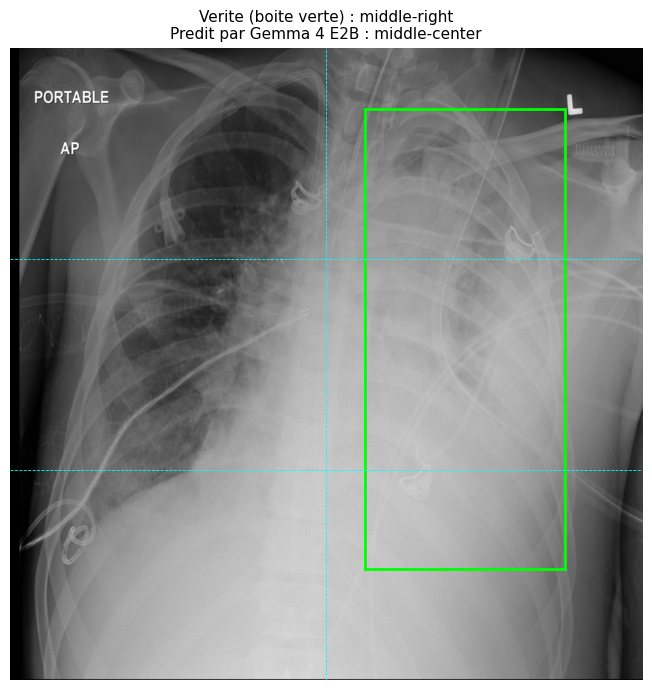

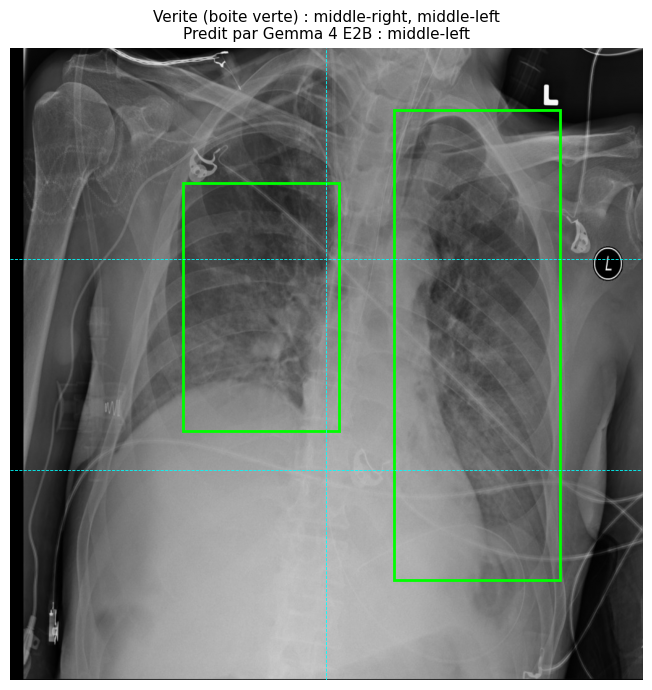

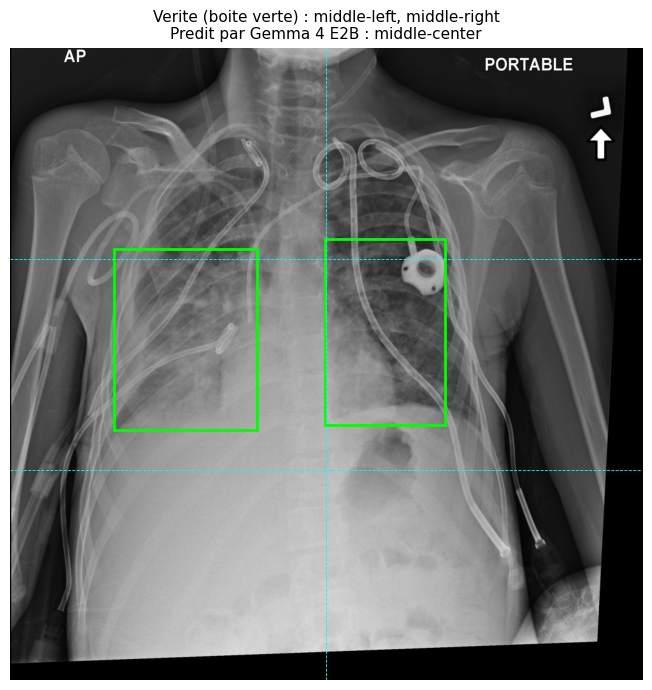

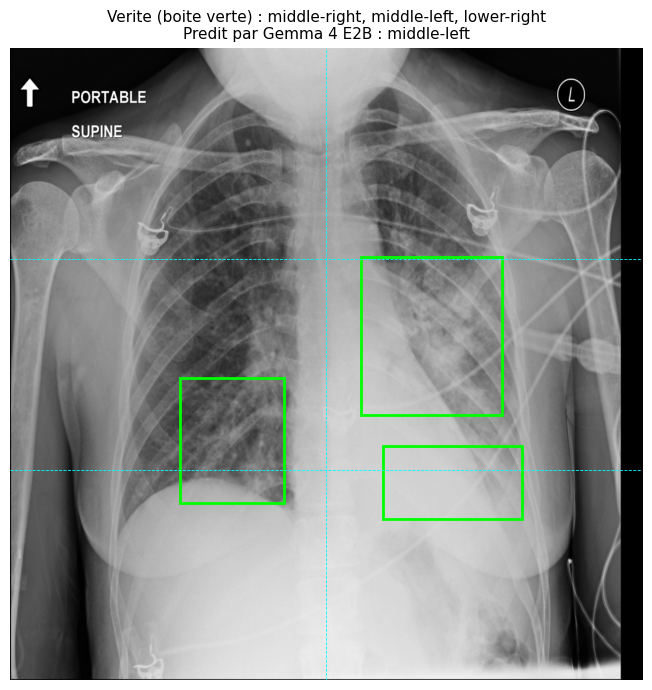

In [22]:
def show_localization(patient_id):
    # Image affichee (taille originale pour aligner les boites)
    path = os.path.join(TRAIN_IMAGES_DIR, f"{patient_id}.dcm")
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array
    img_h, img_w = img.shape

    # Vraie(s) boite(s) + quadrant verite terrain
    rows = boxes_eval[boxes_eval["patientId"] == patient_id]
    true_quads = []
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(img, cmap="gray")
    for _, r in rows.iterrows():
        x, y, w, h = r["x"], r["y"], r["width"], r["height"]
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2,
                     edgecolor="lime", facecolor="none"))
        true_quads.append(box_to_quadrant(x, y, w, h, img_h, img_w))

    # Prediction du modele
    pred_q, note = localize(patient_id)

    # Lignes de quadrant (reperes visuels)
    ax.axvline(img_w / 2, color="cyan", ls="--", lw=0.6)
    ax.axhline(img_h / 3, color="cyan", ls="--", lw=0.6)
    ax.axhline(2 * img_h / 3, color="cyan", ls="--", lw=0.6)

    ax.set_title(f"Verite (boite verte) : {', '.join(true_quads)}\n"
                 f"Predit par Gemma 4 E2B : {pred_q}", fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/loc_{patient_id}.png", dpi=90, bbox_inches="tight")
    plt.show()
    return true_quads, pred_q

# Demonstration sur quelques cas
for pid in boxes_eval["patientId"].drop_duplicates().head(4):
    show_localization(pid)

## 13. Score de localisation : accord prédiction vs vérité

On quantifie sur un échantillon : le quadrant prédit correspond-il à (l'un des) quadrant(s) vérité terrain ? On mesure l'accord exact et l'accord partiel (bon côté horizontal seul).

In [23]:
from tqdm.auto import tqdm

loc_ids = boxes_eval["patientId"].drop_duplicates().head(40).tolist()
exact, horiz_ok, total = 0, 0, 0
records = []

for pid in tqdm(loc_ids):
    rows = boxes_eval[boxes_eval["patientId"] == pid]
    img_h, img_w = get_dicom_size(pid)
    true_quads = {box_to_quadrant(r["x"], r["y"], r["width"], r["height"], img_h, img_w)
                  for _, r in rows.iterrows()}
    pred_q, _ = localize(pid)
    total += 1
    is_exact = pred_q in true_quads
    pred_h = pred_q.split("-")[-1] if "-" in pred_q else "?"
    true_h = {q.split("-")[-1] for q in true_quads}
    is_horiz = pred_h in true_h
    exact += int(is_exact)
    horiz_ok += int(is_horiz)
    records.append({"patientId": pid, "true": "|".join(true_quads),
                    "pred": pred_q, "exact": is_exact, "horiz_ok": is_horiz})

print(f"Cas evalues          : {total}")
print(f"Accord exact quadrant: {exact/total:.2%}")
print(f"Accord cote horizontal: {horiz_ok/total:.2%}")
pd.DataFrame(records).to_csv("/kaggle/working/gemma4e2b_localization.csv", index=False)
print("\nDetail sauvegarde : gemma4e2b_localization.csv")

  0%|          | 0/40 [00:00<?, ?it/s]

Cas evalues          : 40
Accord exact quadrant: 12.50%
Accord cote horizontal: 12.50%

Detail sauvegarde : gemma4e2b_localization.csv


## Notes pour la soutenance

**Partie A (classification, COULD)**
- E2B vs E4B : modèle plus petit, à comparer aux scores MedGemma (mêmes 300 images d'éval).
- Sur-apprentissage du format : seuls `predicted_class` est analysé.

**Partie B (localisation, COULD)**
- Approche *qualitative* assumée : un VLM n'est pas un détecteur d'objets. On compare des
  quadrants, pas des pixels. C'est la limite à expliciter dans le rapport.
- La visualisation (boîte verte = vérité RSNA, titre = quadrant prédit) est la preuve à
  montrer en démo.
- Deux scores : accord exact (quadrant complet) et accord horizontal (côté seul), plus
  indulgent. Attendre des scores modestes — c'est normal et défendable.
- Repère image vs repère patient : sur une radio frontale, le côté gauche de l'image = poumon
  droit du patient. On reste en repère image pour la vérifiabilité visuelle ; à mentionner.

**Couverture MUST/SHOULD/COULD**
- COULD : LoRA Gemma 4 (partie A) + localisation visuelle (partie B) → deux approfondissements.
- Pense à exporter les CSV produits vers ton dashboard de métriques (SHOULD).